# 5.1 Naive key

5.1 Naive key: threshold on green dominance in raw RGB, then key on
chroma alone (hue angle in the YCbCr Cb-Cr plane, which is brightness
invariant unlike raw Cb/Cr distance -- see the derivation in the report).
On this evenly-lit footage the RGB failure is mild (as the handout allows
for); a synthetic darkening sweep constructs the case where it is not.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import to_ycbcr, key_naive_rgb, load_frame_window

ROOT = Path.cwd().parents[1]
CLIP = ROOT / "Images/input/P5/green_screen_clip.mp4"

In [4]:
# Frame 24 of the 48-frame window (see starter.load_frame_window),
# decoded on the fly from the source clip -- no extracted frame files
# are stored in the repo.
frames_48 = load_frame_window(CLIP, n_frames=48)
frame = frames_48[24]
H, W, _ = frame.shape
print(f"frame shape: {frame.shape}")

frame shape: (720, 1280, 3)


In [5]:
# --- RGB-dominance key ---------------------------------------------------
alpha_rgb = key_naive_rgb(frame, thresh=60)
print(f"RGB key: fraction kept as foreground = {alpha_rgb.mean():.3f}")

RGB key: fraction kept as foreground = 0.351


In [6]:
# --- Chroma-only key: hue angle in the Cb-Cr plane ------------------------
# atan2(Cr-128, Cb-128) depends only on the RATIO of (R-Y) to (B-Y), not
# their magnitude, so unlike raw (Cb,Cr) Euclidean distance it is exactly
# invariant to uniform brightness scaling (verified in the report).
key_patch = frame[0:30, 0:30].reshape(-1, 3).astype(np.float64).mean(axis=0)
key_ycc = to_ycbcr(key_patch[None, None, :])[0, 0]
key_angle = np.arctan2(key_ycc[2] - 128.0, key_ycc[1] - 128.0)

In [7]:
ycc = to_ycbcr(frame)
Cb, Cr = ycc[..., 1], ycc[..., 2]
angle = np.arctan2(Cr - 128.0, Cb - 128.0)
angle_diff = np.abs(np.angle(np.exp(1j * (angle - key_angle))))  # wrapped to [0, pi]
ANGLE_THRESH = np.radians(25.0)
alpha_chroma = (angle_diff > ANGLE_THRESH).astype(np.float64)
print(f"Chroma (hue-angle) key: fraction kept as foreground = {alpha_chroma.mean():.3f}")
print(f"estimated key colour RGB={key_patch}, YCbCr={key_ycc}, "
      f"hue angle={np.degrees(key_angle):.1f} deg")

Chroma (hue-angle) key: fraction kept as foreground = 0.330
estimated key colour RGB=[ 61.55       200.81666667  70.20333333], YCbCr=[144.28601333  86.21736848  69.00922249], hue angle=-125.3 deg


In [8]:
backing_strip_angle_diff = angle_diff[0:55, :]
print(f"pure-backing hue-angle deviation: mean={np.degrees(backing_strip_angle_diff.mean()):.2f} deg, "
      f"max={np.degrees(backing_strip_angle_diff.max()):.2f} deg")

pure-backing hue-angle deviation: mean=0.39 deg, max=2.01 deg


In [9]:
# Synthetic darkening sweep: the same backing colour, scaled towards black,
# demonstrates that RGB dominance (an ABSOLUTE difference) crosses below its
# threshold while hue angle (a RATIO) stays exactly fixed.

In [10]:
print("\n=== Synthetic uneven-lighting construction ===")
factors = [1.0, 0.7, 0.5, 0.4, 0.3, 0.2, 0.15, 0.1]
sweep_rows = []
for factor in factors:
    px = key_patch * factor
    dom = px[1] - max(px[0], px[2])
    pycc = to_ycbcr(px[None, None, :])[0, 0]
    pangle = np.arctan2(pycc[2] - 128.0, pycc[1] - 128.0)
    adiff = np.degrees(abs(np.angle(np.exp(1j * (pangle - key_angle)))))
    rgb_verdict = "kept as FG (WRONG)" if dom <= 60 else "keyed out (correct)"
    sweep_rows.append((factor, px, dom, adiff, rgb_verdict))
    print(f"brightness factor={factor:.2f}: RGB={px.astype(int)}  "
          f"dominance={dom:6.1f} (thresh=60 -> {rgb_verdict})   "
          f"hue-angle deviation={adiff:.2f} deg (thresh=25 -> "
          f"{'kept as FG (correct: same hue!)' if adiff <= 25 else 'WRONGLY keyed out'})")


=== Synthetic uneven-lighting construction ===
brightness factor=1.00: RGB=[ 61 200  70]  dominance= 130.6 (thresh=60 -> keyed out (correct))   hue-angle deviation=0.00 deg (thresh=25 -> kept as FG (correct: same hue!))
brightness factor=0.70: RGB=[ 43 140  49]  dominance=  91.4 (thresh=60 -> keyed out (correct))   hue-angle deviation=0.00 deg (thresh=25 -> kept as FG (correct: same hue!))
brightness factor=0.50: RGB=[ 30 100  35]  dominance=  65.3 (thresh=60 -> keyed out (correct))   hue-angle deviation=0.00 deg (thresh=25 -> kept as FG (correct: same hue!))
brightness factor=0.40: RGB=[24 80 28]  dominance=  52.2 (thresh=60 -> kept as FG (WRONG))   hue-angle deviation=0.00 deg (thresh=25 -> kept as FG (correct: same hue!))
brightness factor=0.30: RGB=[18 60 21]  dominance=  39.2 (thresh=60 -> kept as FG (WRONG))   hue-angle deviation=0.00 deg (thresh=25 -> kept as FG (correct: same hue!))
brightness factor=0.20: RGB=[12 40 14]  dominance=  26.1 (thresh=60 -> kept as FG (WRONG))   hu

In [11]:
break_factor = next((f for f, *_, verdict in sweep_rows if "WRONG" in verdict), None)
print(f"\nRGB dominance breaks (wrongly keeps backing as foreground) at brightness "
      f"factor <= {break_factor}; hue angle stays exactly 0.00 deg deviation at every "
      f"factor tested (brightness-invariant by construction).")


RGB dominance breaks (wrongly keeps backing as foreground) at brightness factor <= 0.4; hue angle stays exactly 0.00 deg deviation at every factor tested (brightness-invariant by construction).


In [12]:
# Figure 1: real-frame naive keys side by side

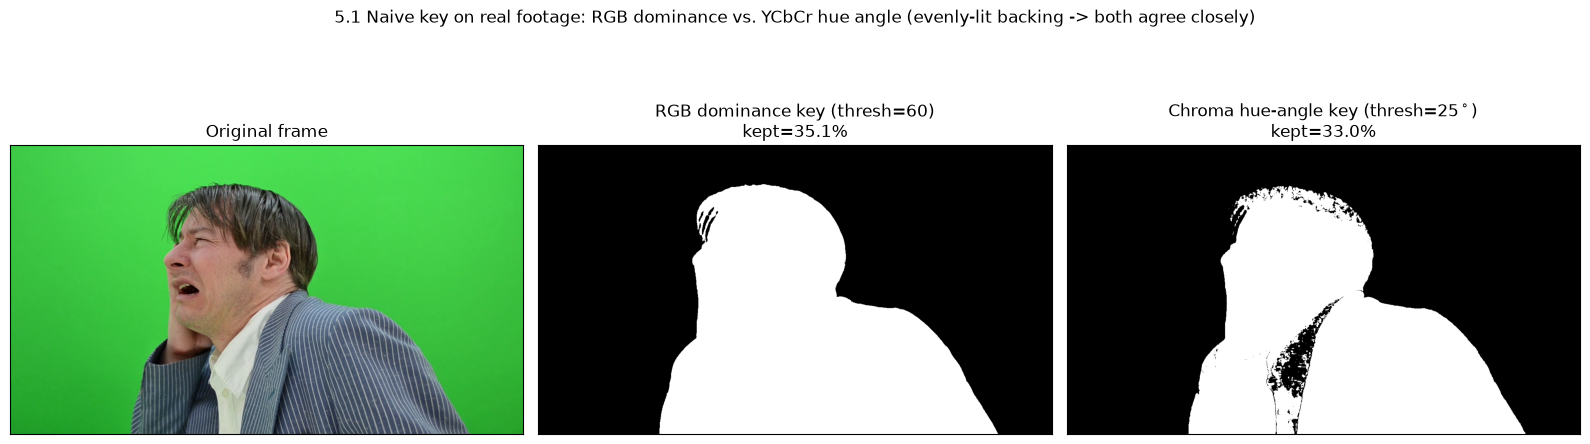

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
axes[0].imshow(frame)
axes[0].set_title("Original frame")
axes[1].imshow(alpha_rgb, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"RGB dominance key (thresh=60)\nkept={alpha_rgb.mean()*100:.1f}%")
axes[2].imshow(alpha_chroma, cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"Chroma hue-angle key (thresh=25$^\\circ$)\nkept={alpha_chroma.mean()*100:.1f}%")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("5.1 Naive key on real footage: RGB dominance vs. YCbCr hue angle "
             "(evenly-lit backing -> both agree closely)")
fig.tight_layout()
plt.show()

In [14]:
# Figure 2: synthetic darkening sweep -- the constructed failure case

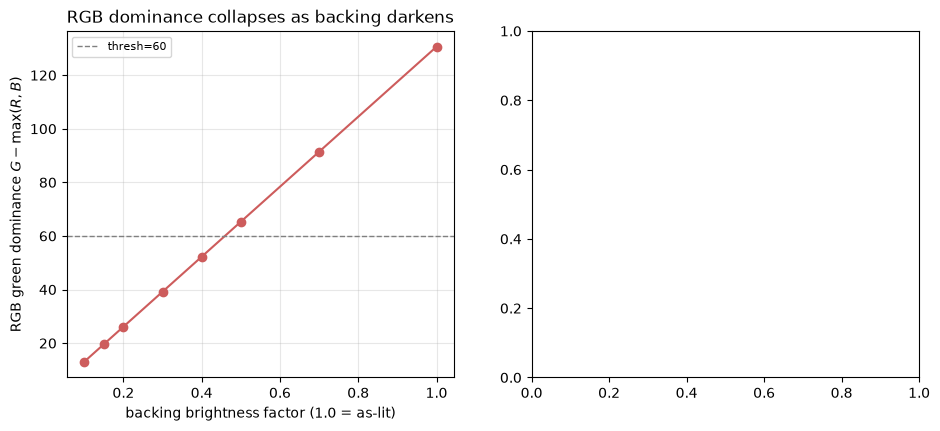

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
doms = [row[2] for row in sweep_rows]
adiffs = [row[3] for row in sweep_rows]
axes[0].plot(factors, doms, "o-", color="indianred")
axes[0].axhline(60, color="gray", linestyle="--", linewidth=1, label="thresh=60")
axes[0].set_xlabel("backing brightness factor (1.0 = as-lit)")
axes[0].set_ylabel("RGB green dominance $G-\\max(R,B)$")
axes[0].set_title("RGB dominance collapses as backing darkens")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

In [16]:
axes[1].plot(factors, adiffs, "o-", color="steelblue")
axes[1].axhline(25, color="gray", linestyle="--", linewidth=1, label="thresh=25$^\\circ$")
axes[1].set_xlabel("backing brightness factor (1.0 = as-lit)")
axes[1].set_ylabel("hue-angle deviation from key (deg)")
axes[1].set_ylim(-2, 30)
axes[1].set_title("Hue angle is exactly brightness-invariant")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
fig.suptitle("Constructed uneven-lighting failure: same backing colour, scaled darker")
fig.tight_layout()
plt.show()